# 119番通報 緊急度判定プロトコル — 遷移図

`dataset/protocol_priority_reviewed.yaml` から症候別の遷移図を Graphviz で生成する。

**前提パッケージ**

```bash
pip install pyyaml graphviz
# Graphviz本体（macOS）: brew install graphviz
```

**レイアウトの取り決め**

| 形状 | 意味 |
|---|---|
| ◇ ひし形 | 選択肢を持つ判定ノード（質問） |
| ▱ 平行四辺形 | 情報収集ノード（`metadata_only`、緊急度に影響しない） |
| ⬭ 楕円 | トリアージ確定ノード（葉） |
| ⬜ 帯状 | 外部プロトコルへのルーティング先 |
| 付箋 | プロトコルの fallback ルール |

**色（トリアージ）**

- 赤: R1 / R2 / R3（Very urgent）
- 黄: Y1 / Y2（Semi-urgent）
- 緑: G（Low urgency）

## 1. セットアップ

In [44]:
import os
import yaml
from pathlib import Path
from graphviz import Digraph
os.environ["PATH"] += os.pathsep + r"C:\Users\hiyok\scoop\shims"

from IPython.display import display, Markdown

YAML_PATH = Path("dataset/protocol_priority_reviewed.yaml")
with YAML_PATH.open(encoding="utf-8") as f:
    data = yaml.safe_load(f)

labels         = data["labels"]
entry_flow     = {n["id"]: n for n in data["entry_flow"]}
common_vitals  = {n["id"]: n for n in data["common_vitals"]}
router         = data["chief_complaint_router"]
protocols      = {p["id"]: p for p in data["protocols"]}

print(f"プロトコル数: {len(protocols)}")
print(f"共通バイタルノード数: {len(common_vitals)}")
print("プロトコル一覧:")
for pid, p in protocols.items():
    print(f"  - {pid}: {p.get('name', '')}")


プロトコル数: 22
共通バイタルノード数: 4
プロトコル一覧:
  - dyspnea: 呼吸困難
  - palpitation: 動悸
  - consciousness_disorder_syncope: 意識障害／失神
  - convulsion: けいれん
  - headache: 頭痛
  - chest_pain_nontraumatic: 胸痛（非外傷性）
  - back_pain: 背部痛
  - lumbar_pain: 腰部痛
  - adult_fever: 成人の発熱（16歳以上）
  - abdominal_pain: 腹痛
  - adult_nausea_vomiting: 成人の嘔気・嘔吐（16歳以上）
  - dizziness: めまい
  - numbness: しびれ
  - hematemesis_hemoptysis: 吐血・喀血
  - melena_hematochezia: 下血・血便
  - malaise: 具合が悪い・気分が悪い
  - trauma: 外傷
  - foreign_body_ingestion: 固形物誤飲
  - poisoning: 中毒
  - pediatric_fever: 小児の発熱（16歳未満）
  - pediatric_nausea_vomiting: 小児の嘔気・嘔吐（16歳未満）
  - pediatric_head_neck_trauma: 小児の頭・頸部外傷（16歳未満）


## 2. 描画ヘルパー

In [45]:
# トリアージ色
TRIAGE_FILL = {
    "R1": "#e74c3c", "R2": "#e74c3c", "R3": "#c0392b",
    "Y1": "#f1c40f", "Y2": "#f4d03f",
    "G":  "#27ae60",
}
TRIAGE_FONT = {
    "R1": "white", "R2": "white", "R3": "white",
    "Y1": "black", "Y2": "black",
    "G":  "white",
}

# 日本語フォント（macOS既定）
FONT = "Meiryo"

def _trim(text: str, n: int = 28) -> str:
    text = (text or "").replace("\n", " ").strip()
    return text if len(text) <= n else text[: n - 1] + "…"

def _new_graph(title: str) -> Digraph:
    g = Digraph()
    g.attr(rankdir="TB", label=title, labelloc="t",
           fontname=FONT, fontsize="16", splines="spline", nodesep="0.35", ranksep="0.45")
    g.attr("node", fontname=FONT, fontsize="11", margin="0.12,0.06")
    g.attr("edge", fontname=FONT, fontsize="9")
    return g

def _terminal(g: Digraph, parent: str, edge_label: str, triage: str, oral=None, idx=[0]):
    """葉ノード（トリアージ）を生成して親から辺を引く。idxで一意化。"""
    idx[0] += 1
    tid = f"__term_{parent}_{idx[0]}"
    text = triage
    if oral:
        text += "\n口頭指導: " + ", ".join(oral)
    g.node(tid, text,
           shape="ellipse", style="filled,bold",
           fillcolor=TRIAGE_FILL.get(triage, "#bdc3c7"),
           fontcolor=TRIAGE_FONT.get(triage, "black"))
    g.edge(parent, tid, label=_trim(edge_label, 16))

def _question_node(g: Digraph, nid: str, question: str):
    g.node(nid, _trim(question, 30),
           shape="diamond", style="filled", fillcolor="#fdf2e9")

def _info_node(g: Digraph, nid: str, question: str):
    g.node(nid, "[情報収集]\n" + _trim(question, 28),
           shape="parallelogram", style="filled", fillcolor="#d6eaf8")

def _route_node(g: Digraph, tgt_id: str, label: str):
    g.node(tgt_id, label,
           shape="cds", style="filled,dashed", fillcolor="#fadbd8")

def _add_choices(g: Digraph, parent: str, choices):
    for ch in choices or []:
        etext = ch.get("text", ch.get("code", ""))
        if "triage" in ch:
            _terminal(g, parent, etext, ch["triage"], ch.get("oral_instruction"))
        elif "next" in ch:
            g.edge(parent, ch["next"], label=_trim(etext, 16))
        elif ch.get("route_to_protocol"):
            tgt = f"__proto_{ch['route_to_protocol']}"
            _route_node(g, tgt, f"→ {ch['route_to_protocol']}")
            g.edge(parent, tgt, label=_trim(etext, 16))
        elif ch.get("route_to"):
            tgt = f"__route_{ch['route_to']}"
            _route_node(g, tgt, ch["route_to"])
            g.edge(parent, tgt, label=_trim(etext, 16))


## 3. エントリ → 共通バイタル → 主訴ルーター（共通フロー）

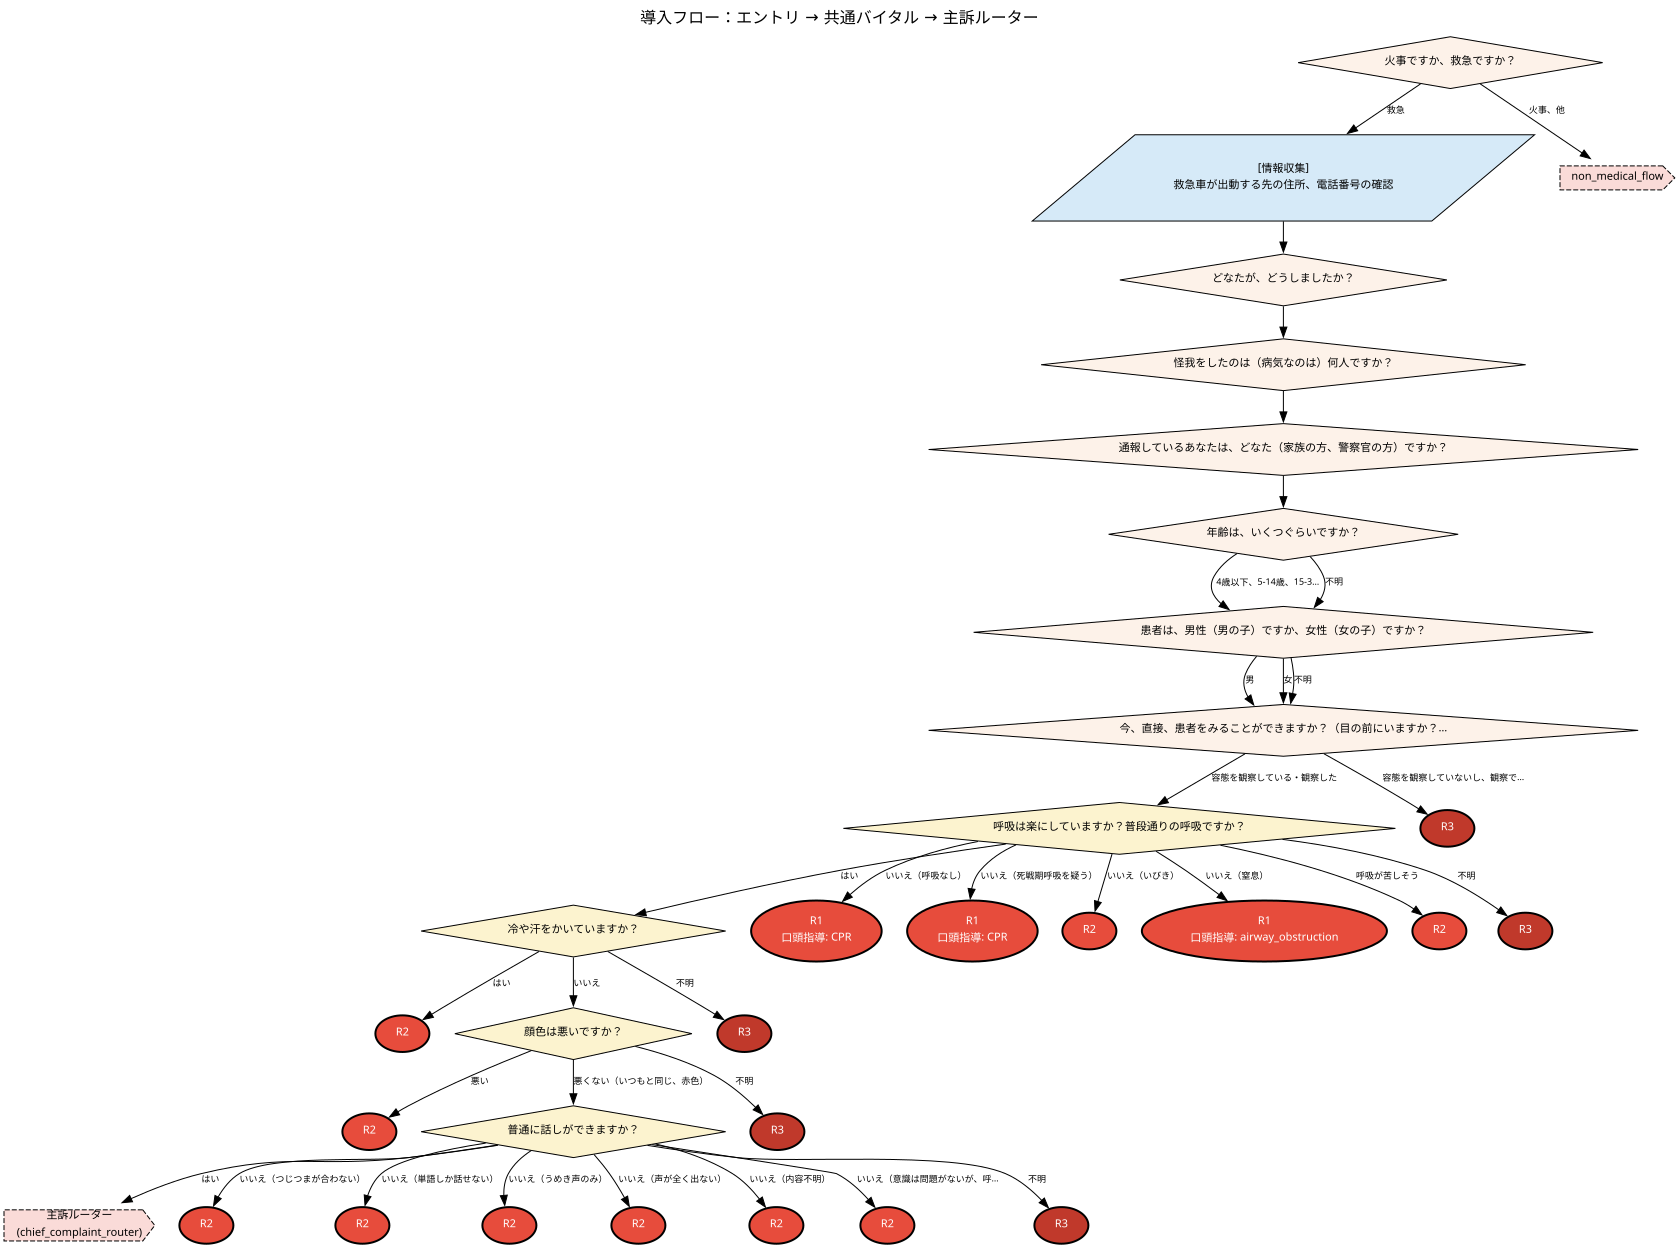

In [46]:
def render_common_flow() -> Digraph:
    g = _new_graph("導入フロー：エントリ → 共通バイタル → 主訴ルーター")

    # entry_flow
    for nid, node in entry_flow.items():
        q = node.get("question", nid)
        if node.get("metadata_only"):
            _info_node(g, nid, q)
        else:
            _question_node(g, nid, q)
        if "next" in node:
            g.edge(nid, node["next"])
        _add_choices(g, nid, node.get("choices"))

    # common_vitals（黄色寄りの判定ノードで区別）
    for nid, node in common_vitals.items():
        q = node.get("question", nid)
        g.node(nid, _trim(q, 30),
               shape="diamond", style="filled", fillcolor="#fcf3cf")
        _add_choices(g, nid, node.get("choices"))

    # 主訴ルーター（外部）
    _route_node(g, "chief_complaint_router", "主訴ルーター\n(chief_complaint_router)")
    return g

display(render_common_flow())


## 4. 主訴ルーター（症候→プロトコル）

主訴キーワードから各症候プロトコルへの分岐を可視化。

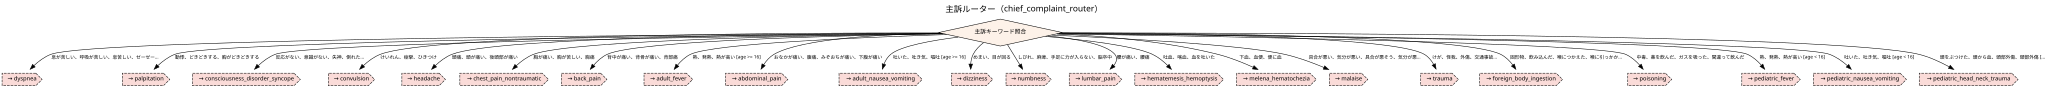

In [47]:
def render_router() -> Digraph:
    g = _new_graph("主訴ルーター（chief_complaint_router）")
    g.node("__router", "主訴キーワード照合",
           shape="diamond", style="filled", fillcolor="#fdf2e9")
    for r in router["routes"]:
        pid = r["protocol"]
        kws = "、".join(r.get("match_any", [])[:4])
        if len(r.get("match_any", [])) > 4:
            kws += "…"
        cond = r.get("age_condition")
        edge_label = kws + (f"\n[{cond}]" if cond else "")
        tgt = f"__proto_{pid}"
        _route_node(g, tgt, f"→ {pid}")
        g.edge("__router", tgt, label=_trim(edge_label, 24))
    return g

display(render_router())


## 5. 症候別プロトコル

`render_protocol(pid)` で個別レンダリング、ループで全プロトコル一括表示。

In [48]:
def render_protocol(pid: str) -> Digraph:
    proto = protocols[pid]
    title = f"{proto.get('name','')}  ({pid})"
    if proto.get("source_pages"):
        title += f"  — pp.{','.join(map(str, proto['source_pages']))}"
    g = _new_graph(title)

    # 開始疑似ノード
    entry = f"__entry_{pid}"
    if proto.get("start_after_common_vitals"):
        g.node(entry, "共通バイタル後", shape="cds", style="filled", fillcolor="#ecf0f1")
    else:
        g.node(entry, "開始", shape="circle", style="filled", fillcolor="#ecf0f1")

    nodes = proto.get("nodes", [])
    if nodes:
        g.edge(entry, nodes[0]["id"])

    for node in nodes:
        nid = node["id"]
        q   = node.get("question", nid)

        # ノード自身がトリアージ確定（葉）
        if "triage" in node and "choices" not in node:
            t = node["triage"]
            g.node(nid, _trim(q, 30) + f"\n→ {t}",
                   shape="ellipse", style="filled,bold",
                   fillcolor=TRIAGE_FILL.get(t, "#bdc3c7"),
                   fontcolor=TRIAGE_FONT.get(t, "black"))
            continue

        # 情報収集のみ
        if node.get("metadata_only"):
            _info_node(g, nid, q)
            continue

        # 通常の判定ノード
        _question_node(g, nid, q)
        _add_choices(g, nid, node.get("choices"))

    # fallback の付箋
    fb = proto.get("fallback")
    if fb:
        parts = []
        if "if_any_unknown" in fb:
            parts.append(f"不明あり → {fb['if_any_unknown']}")
        if "if_all_symptom_questions_negative" in fb:
            parts.append(f"全て陰性 → {fb['if_all_symptom_questions_negative']}")
        g.node(f"__fb_{pid}", "fallback\n" + "\n".join(parts),
               shape="note", style="filled", fillcolor="#fdebd0")

    return g


### 5.1 個別表示の例

#### 呼吸困難 (dyspnea)

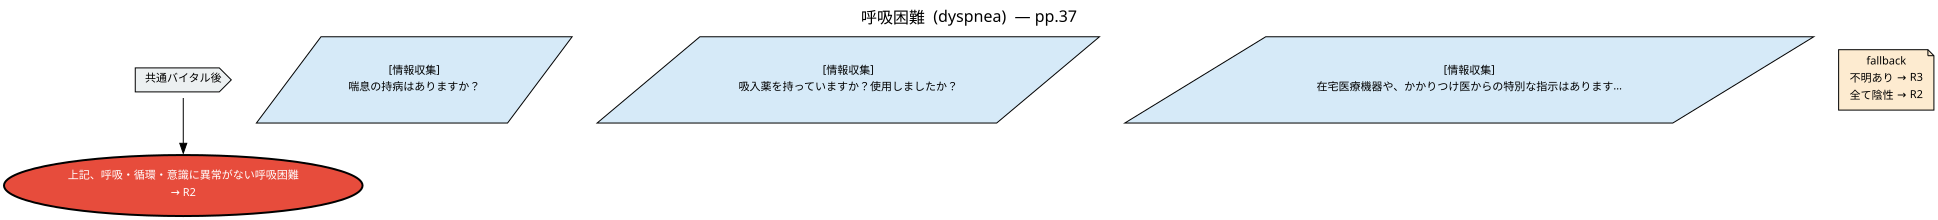

In [49]:
# 任意のプロトコルだけを描く例
display(Markdown("#### 呼吸困難 (dyspnea)"))
display(render_protocol("dyspnea"))


### 5.2 全プロトコル一括表示

#### 呼吸困難 (`dyspnea`)

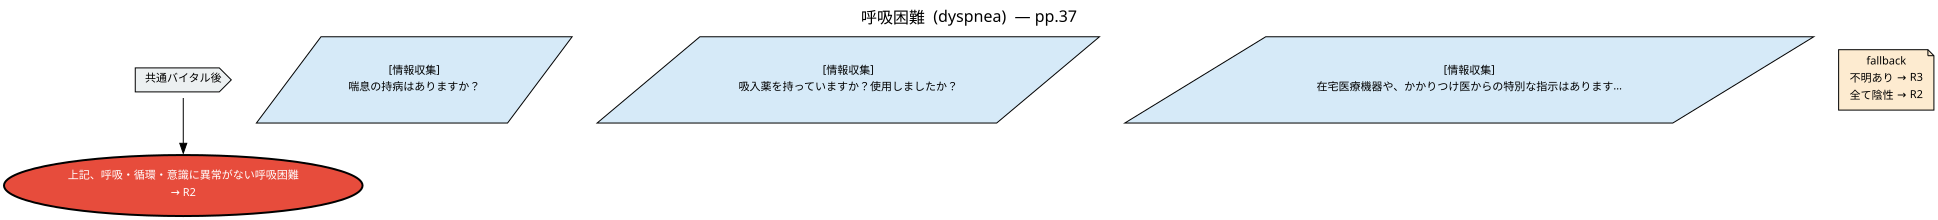

#### 動悸 (`palpitation`)

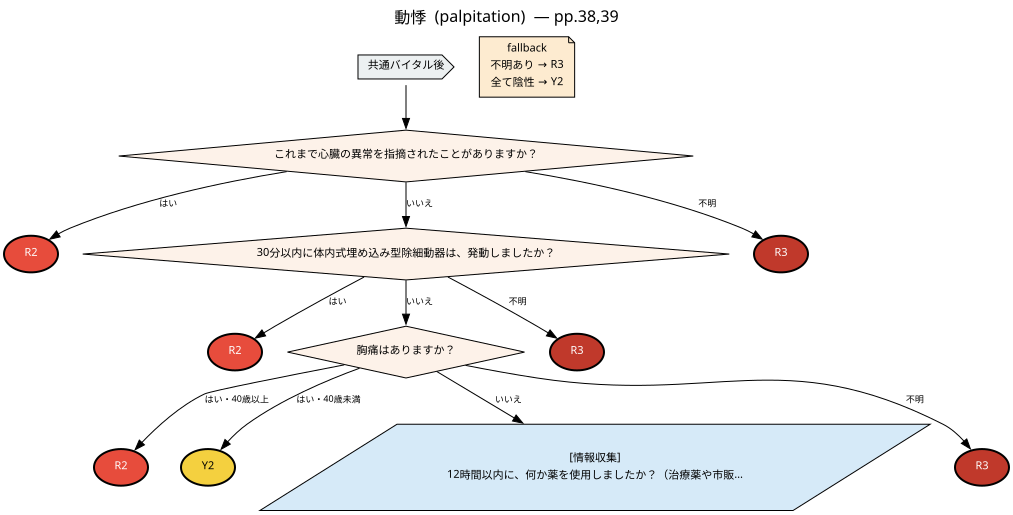

#### 意識障害／失神 (`consciousness_disorder_syncope`)

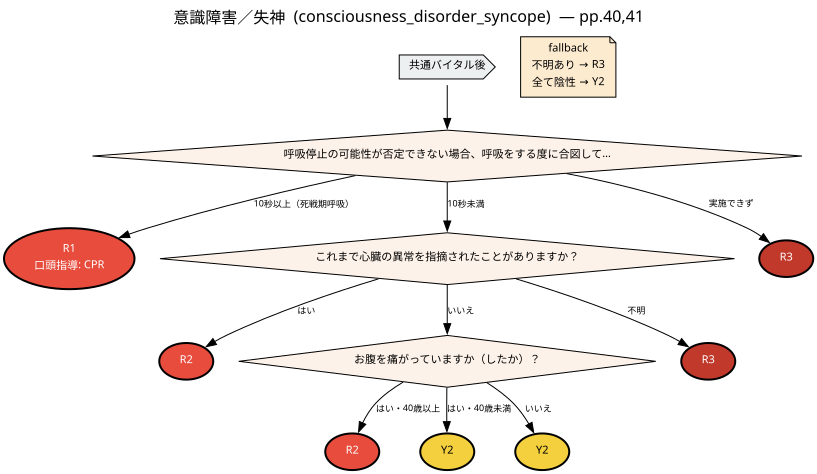

#### けいれん (`convulsion`)

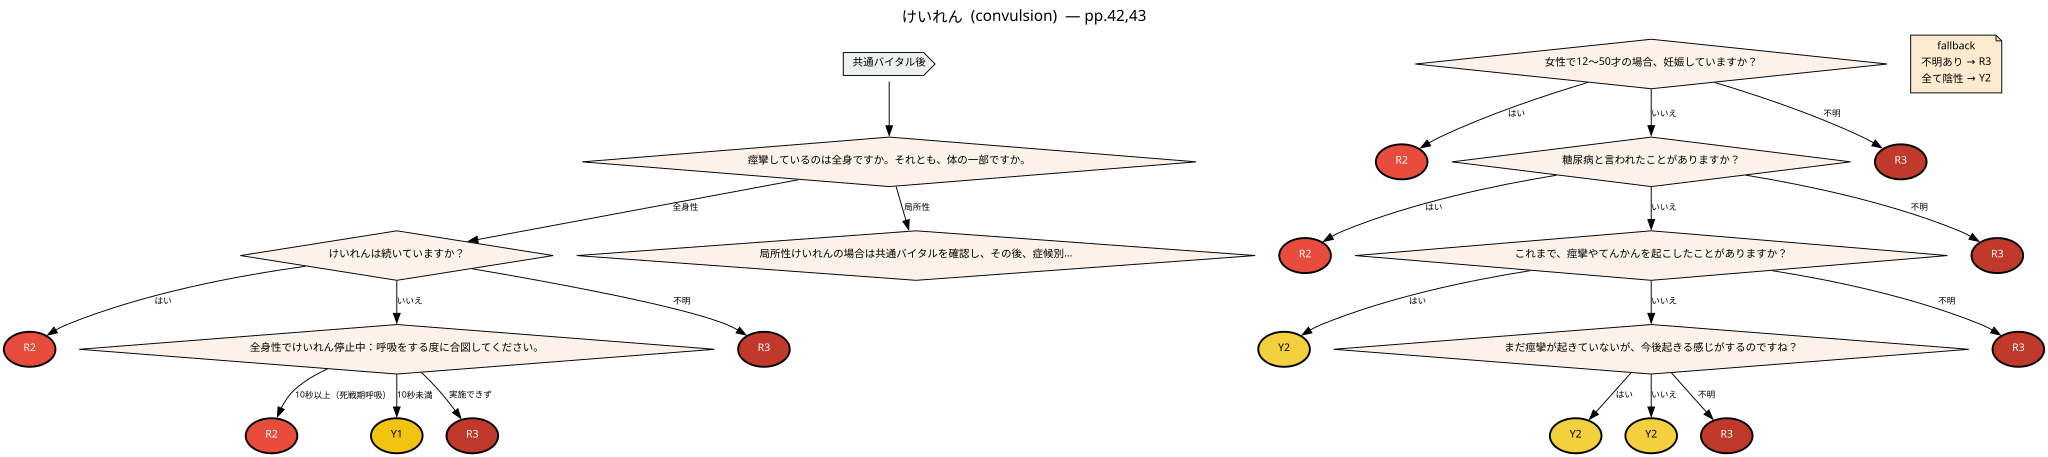

#### 頭痛 (`headache`)

KeyboardInterrupt: 

In [50]:
for pid, proto in protocols.items():
    display(Markdown(f"#### {proto.get('name', pid)} (`{pid}`)"))
    display(render_protocol(pid))


In [ ]:
def render_common_flow() -> Digraph:
    g = _new_graph("導入フロー：エントリ → 共通バイタル → 主訴ルーター")

    # entry_flow
    for nid, node in entry_flow.items():
        q = node.get("question", nid)
        if node.get("metadata_only"):
            _info_node(g, nid, q)
        else:
            _question_node(g, nid, q)
        if "next" in node:
            g.edge(nid, node["next"])
        _add_choices(g, nid, node.get("choices"))

    # common_vitals（黄色寄りの判定ノードで区別）
    for nid, node in common_vitals.items():
        q = node.get("question", nid)
        g.node(nid, _trim(q, 30),
               shape="diamond", style="filled", fillcolor="#fcf3cf")
        _add_choices(g, nid, node.get("choices"))

    # 主訴ルーター（外部）
    _route_node(g, "chief_complaint_router", "主訴ルーター\n(chief_complaint_router)")
    return g

display(render_common_flow())


## 6. ファイル保存（任意）

PNG/SVG として `diagrams/` に書き出す場合は次セルを実行。

In [ ]:
OUT_DIR = Path("diagrams")
OUT_DIR.mkdir(exist_ok=True)

# 共通フロー
render_common_flow().render(OUT_DIR / "00_common_flow", format="svg", cleanup=True)
render_router().render(OUT_DIR / "01_router", format="svg", cleanup=True)

# 各プロトコル
for i, pid in enumerate(protocols, start=2):
    g = render_protocol(pid)
    g.render(OUT_DIR / f"{i:02d}_{pid}", format="svg", cleanup=True)

print(f"saved to {OUT_DIR.resolve()}")


In [ ]:
from pathlib import Path

OUT_DIR = Path("diagrams")
OUT_DIR.mkdir(exist_ok=True)

for i, (pid, proto) in enumerate(protocols.items(), start=1):
    g = render_protocol(pid)
    out = g.render(OUT_DIR / f"{i:02d}_{pid}", format="pdf", cleanup=True)
    print(f"saved: {out}")
